In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("/Users/huytq130/Desktop/thesis/data_survey.xlsx", sheet_name="dataset")

In [3]:
groups_full_header = df.columns
group_idx = [i for i, j in enumerate(groups_full_header) if "Unnamed" not in j]
columns = df.iloc[0, :].values

column_to_group = []
group_map = {idx: [] for idx in group_idx} # Initialize group_map with group_idx values as keys

if group_idx: # Ensure group_idx is not empty
    current_group_idx_pointer = 0
    current_group_id_value = group_idx[0]

    for i, col_name in enumerate(columns):
        # Check if the current column 'i' has crossed into the next major group's territory
        if current_group_idx_pointer + 1 < len(group_idx) and i >= group_idx[current_group_idx_pointer + 1]:
            current_group_idx_pointer += 1
            current_group_id_value = group_idx[current_group_idx_pointer]

        column_to_group.append(current_group_id_value)
        group_map[current_group_id_value].append(col_name)
else:
    # If no groups are found, then column_to_group will be empty and group_map will be empty
    column_to_group = []
    group_map = {}


In [4]:
data_df = df.iloc[2:, :]
data_df.columns = columns

In [5]:
phq_columns = [f'phq_{i}' for i in range(1, 10)]
data_df['phq_total'] = data_df[phq_columns].sum(axis=1) - 9
display(data_df)

/var/folders/hf/279rd5mj39s2ylzfftxy9gdh0000gq/T/ipykernel_68032/2185937434.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df['phq_total'] = data_df[phq_columns].sum(axis=1) - 9


,gioi_tinh,xu_huong_tinh_duc,ton_giao,tinh_trang_sinh_song,tinh_trang_hoc_luc,nganh_hoc_phu_hop,lam_them,so_luong_cong_viec,tan_suat_lam_them,ap_luc_diem_so,...,phq_1,phq_2,phq_3,phq_4,phq_5,phq_6,phq_7,phq_8,phq_9,phq_total
2,0,0,1,3,3,3,1,1,15,1,...,1,3,2,2,2,3,2,2,2,10
3,0,0,2,1,1,2,1,1,25,1,...,4,4,4,4,4,4,4,4,4,27
4,0,0,2,1,3,2,1,2,40,0,...,1,1,1,1,1,1,1,1,1,0
5,0,0,1,1,3,3,0,0,0,2,...,3,3,2,3,3,2,2,1,1,11
6,0,0,2,1,4,3,1,1,40,3,...,4,4,4,4,4,4,4,4,4,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826,0,0,0,1,2,3,0,0,0,3,...,3,3,3,3,2,4,3,4,1,17
827,1,0,0,1,3,3,1,1,25,3,...,2,1,2,3,1,1,1,1,1,4
828,0,0,0,0,2,2,1,1,0,2,...,1,1,1,1,1,1,2,1,1,1
829,0,0,1,1,2,2,1,1,15,0,...,2,1,2,2,2,1,1,1,2,5


In [6]:
input_cols = [col for col in data_df.columns if 'phq' not in col]
target_col = "phq_total"
print("Shape:", data_df.shape)
print("\nColumns:", len(data_df.columns))
print("\nTarget:", target_col)

data_df.head()

Shape: (829, 59)

Columns: 59

Target: phq_total


,gioi_tinh,xu_huong_tinh_duc,ton_giao,tinh_trang_sinh_song,tinh_trang_hoc_luc,nganh_hoc_phu_hop,lam_them,so_luong_cong_viec,tan_suat_lam_them,ap_luc_diem_so,...,phq_1,phq_2,phq_3,phq_4,phq_5,phq_6,phq_7,phq_8,phq_9,phq_total
2,0,0,1,3,3,3,1,1,15,1,...,1,3,2,2,2,3,2,2,2,10
3,0,0,2,1,1,2,1,1,25,1,...,4,4,4,4,4,4,4,4,4,27
4,0,0,2,1,3,2,1,2,40,0,...,1,1,1,1,1,1,1,1,1,0
5,0,0,1,1,3,3,0,0,0,2,...,3,3,2,3,3,2,2,1,1,11
6,0,0,2,1,4,3,1,1,40,3,...,4,4,4,4,4,4,4,4,4,27


## EDA

count     829
unique     28
top         0
freq       79
Name: phq_total, dtype: int64


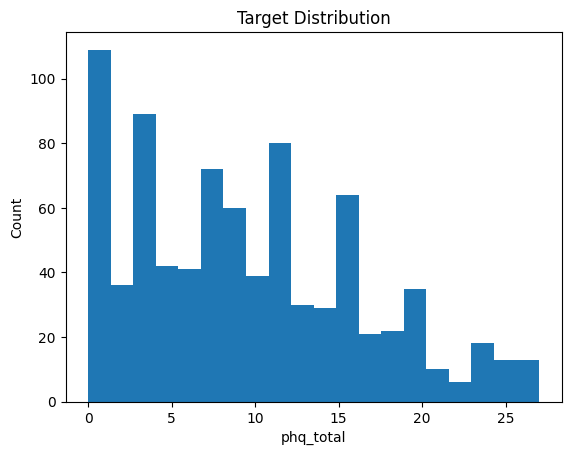

In [7]:
import matplotlib.pyplot as plt

print(data_df[target_col].describe())

plt.hist(data_df[target_col], bins=20)
plt.title("Target Distribution")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.show()

In [8]:
missing = data_df[input_cols + [target_col]].isna().mean().sort_values(ascending=False)
print(missing.head(20))

tan_suat_choi_the_thao              0.004825
thoi_luong_dung_mang_xh             0.003619
lo_so_doi_xu_bat_con_do_can_nang    0.000000
bi_body_shaming                     0.000000
tung_bi_bao_luc                     0.000000
tung_bi_xuc_pham                    0.000000
tung_bi_de_doa                      0.000000
bi_quay_roi_online                  0.000000
tu_lam_hai_ban_than                 0.000000
y_nghi_tu_tu                        0.000000
bi_xam_hai_tinh_duc                 0.000000
co_choi_the_thao                    0.000000
gioi_tinh                           0.000000
xu_huong_tinh_duc                   0.000000
bị_benh_man_tinh                    0.000000
duọc_chan_doan_tam_ly               0.000000
tung_tri_lieu_tam_ly                0.000000
gad_1                               0.000000
gad_2                               0.000000
gad_3                               0.000000
dtype: float64


In [9]:
nunique = data_df[input_cols].nunique().sort_values()

print("Low variance columns:")
print(nunique[nunique <= 1])

Low variance columns:
Series([], dtype: int64)


In [10]:

for col in [target_col]:
    print(col, "min:", data_df[col].min(), "max:", data_df[col].max())

phq_total min: 0 max: 27


In [11]:

corr = data_df[input_cols].corrwith(data_df[target_col]).sort_values(ascending=False)

print("Top positive correlations:")
print(corr.head(10))

print("\nTop negative correlations:")
print(corr.tail(10))

Top positive correlations:
gad_1                      0.736429
gad_3                      0.721497
gad_2                      0.718901
gad_4                      0.708277
gad_7                      0.643603
gad_5                      0.624343
gad_6                      0.618818
cam_giac_bi_bo_roi         0.492750
ap_luc_hoc_tap_cam_nhan    0.470489
cam_giac_bi_co_lap         0.446710
dtype: float64

Top negative correlations:
tinh_trang_sinh_song      0.052263
so_luong_cong_viec        0.040933
tan_suat_lam_them         0.030059
nguoi_chi_tra_hoc_phi     0.015044
lam_them                 -0.008578
tinh_trang_hoc_luc       -0.012109
xu_huong_tinh_duc        -0.017133
tan_suat_choi_the_thao   -0.139203
co_choi_the_thao         -0.162636
tinh_hinh_tai_chinh      -0.286310
dtype: float64


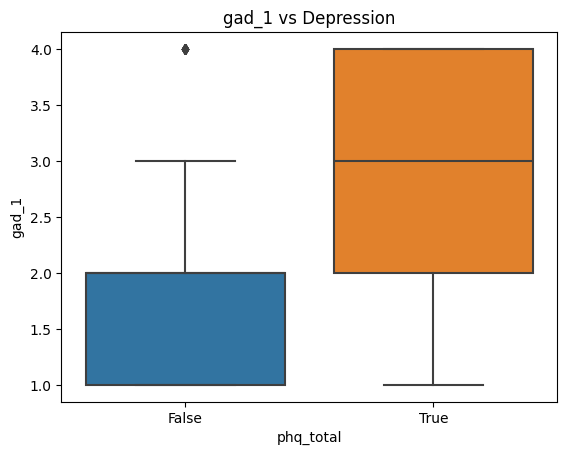

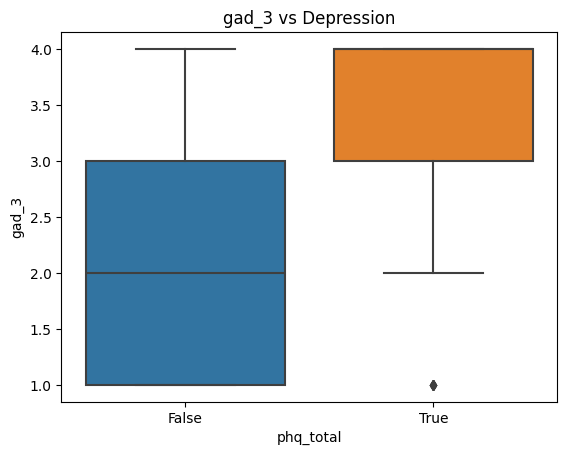

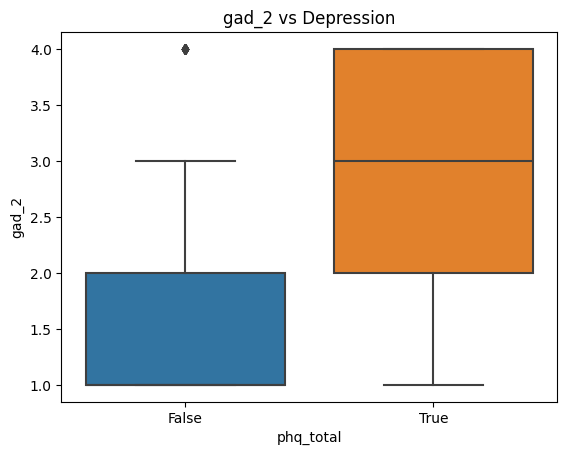

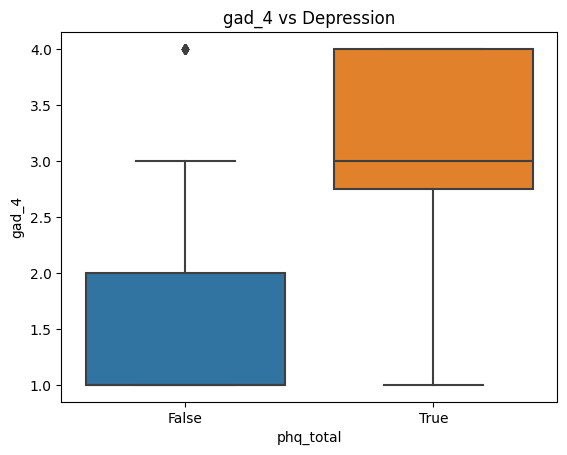

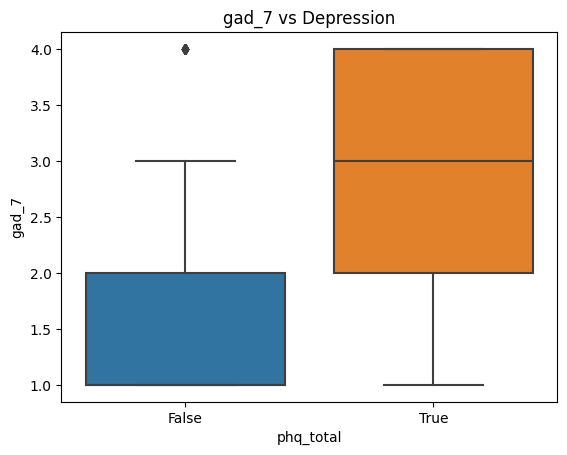

In [12]:

import seaborn as sns

top_features = corr.abs().sort_values(ascending=False).head(5).index

for col in top_features:
    sns.boxplot(x=data_df[target_col] > 15, y=data_df[col])
    plt.title(f"{col} vs Depression")
    plt.show()

In [13]:
corr_matrix = data_df[input_cols].corr().abs()

high_corr = (
    corr_matrix.where(corr_matrix > 0.0)
    .stack()
    .reset_index()
)
high_corr

,level_0,level_1,0
0,gioi_tinh,gioi_tinh,1.000000
1,gioi_tinh,xu_huong_tinh_duc,0.000768
2,gioi_tinh,ton_giao,0.020404
3,gioi_tinh,tinh_trang_sinh_song,0.013992
4,gioi_tinh,tinh_trang_hoc_luc,0.098731
...,...,...,...
2396,gad_7,gad_3,0.580556
2397,gad_7,gad_4,0.552874
2398,gad_7,gad_5,0.512454
2399,gad_7,gad_6,0.651620


In [14]:
corr_matrix = data_df[input_cols].corr().abs()

high_corr = (
    corr_matrix.where(corr_matrix > 0.9)
    .stack()
    .reset_index()
)

print(high_corr.head(10))

                level_0               level_1    0
0             gioi_tinh             gioi_tinh  1.0
1     xu_huong_tinh_duc     xu_huong_tinh_duc  1.0
2              ton_giao              ton_giao  1.0
3  tinh_trang_sinh_song  tinh_trang_sinh_song  1.0
4    tinh_trang_hoc_luc    tinh_trang_hoc_luc  1.0
5     nganh_hoc_phu_hop     nganh_hoc_phu_hop  1.0
6              lam_them              lam_them  1.0
7    so_luong_cong_viec    so_luong_cong_viec  1.0
8     tan_suat_lam_them     tan_suat_lam_them  1.0
9        ap_luc_diem_so        ap_luc_diem_so  1.0


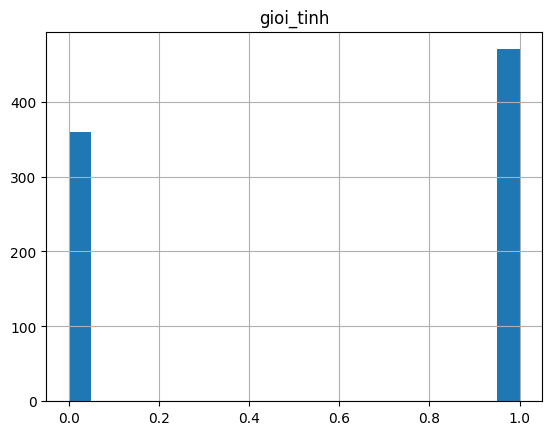

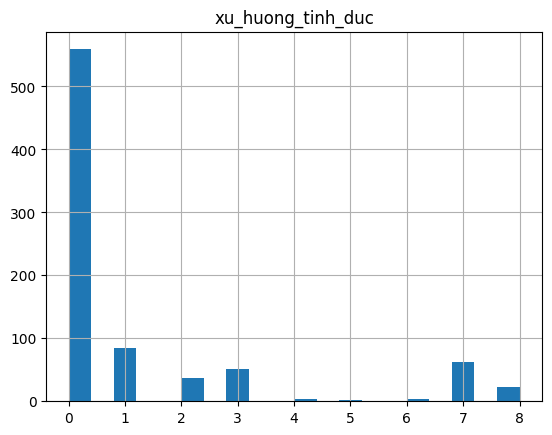

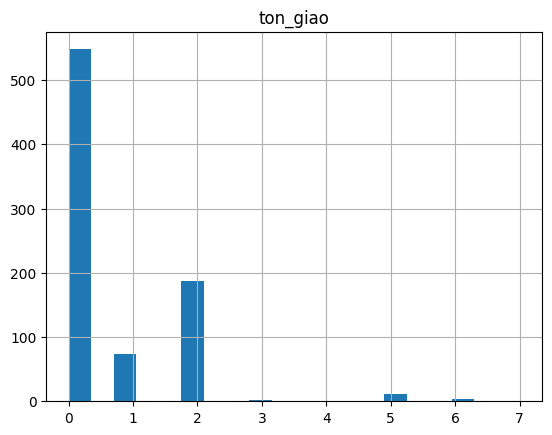

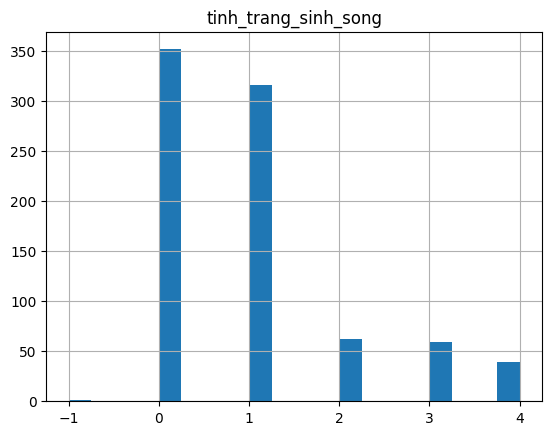

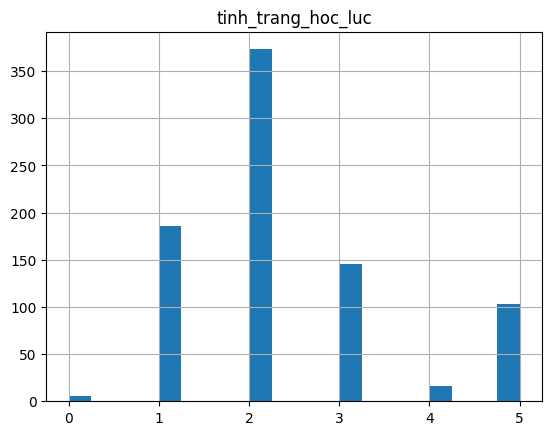

In [15]:
for col in input_cols[:5]:  # chọn vài biến
    data_df[col].hist(bins=20)
    plt.title(col)
    plt.show()

## CFA

In [16]:
# =========================
# 1. Define item groups
# =========================

phq_items = [f"phq_{i}" for i in range(1, 10)]
gad_items = [f"gad_{i}" for i in range(1, 8)]

academic_items = [
    "ap_luc_diem_so",
    "ap_luc_hoc_tap_cam_nhan",
    "ap_luc_hoc_tap_tu_gia_dinh",
]

financial_items = [
    "tinh_hinh_tai_chinh",
    "kho_khan_do_chi_phi_sinh_hoat",
    "lo_lang_ve_dieu_kien_song",
]

social_items = [
    "cam_giac_bi_co_lap",
    "cam_giac_bi_bo_roi",
    "thieu_nguoi_dong_hanh",
]

body_items = [
    "cam_thay_map",
    "cam_thay_phai_gay_hon",
    "lo_so_doi_xu_bat_con_do_can_nang",
    "bi_body_shaming",
]

trauma_items = [
    "tung_bi_bao_luc",
    "tung_bi_xuc_pham",
    "tung_bi_de_doa",
    "bi_quay_roi_online",
    "bi_xam_hai_tinh_duc",
]

cfa_cols = (
    phq_items
    + gad_items
    + academic_items
    + financial_items
    + social_items
    + body_items
    + trauma_items
)

In [17]:
# cfa_cols = [c for c in cfa_cols if c in data_df.columns]

df_cfa = data_df[cfa_cols].copy()


df_cfa = df_cfa.apply(pd.to_numeric, errors="coerce")
df_cfa = df_cfa.fillna(df_cfa.median())

In [18]:
model_desc = """
Depression =~ phq_1 + phq_2 + phq_3 + phq_4 + phq_5 + phq_6 + phq_7 + phq_8 + phq_9

Anxiety =~ gad_1 + gad_2 + gad_3 + gad_4 + gad_5 + gad_6 + gad_7

AcademicStress =~ ap_luc_diem_so + ap_luc_hoc_tap_cam_nhan + ap_luc_hoc_tap_tu_gia_dinh

FinancialStress =~ tinh_hinh_tai_chinh + kho_khan_do_chi_phi_sinh_hoat + lo_lang_ve_dieu_kien_song

SocialIsolation =~ cam_giac_bi_co_lap + cam_giac_bi_bo_roi + thieu_nguoi_dong_hanh

BodyImageStress =~ cam_thay_map + cam_thay_phai_gay_hon + lo_so_doi_xu_bat_con_do_can_nang + bi_body_shaming

VictimizationTrauma =~ tung_bi_bao_luc + tung_bi_xuc_pham + tung_bi_de_doa + bi_quay_roi_online + bi_xam_hai_tinh_duc
"""

from semopy import Model, calc_stats

cfa_model = Model(model_desc)
cfa_model.fit(df_cfa)

stats = calc_stats(cfa_model)
print(stats)

       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  506           561  1446.244601           0.0   12925.518936  0.923956   

            GFI      AGFI       NFI       TLI     RMSEA         AIC  \
Value  0.888109  0.875947  0.888109  0.915691  0.047373  174.510869   

              BIC    LogLik  
Value  594.610463  1.744565  


In [19]:
# =========================
# 5. Inspect loadings
# =========================

params = cfa_model.inspect()

loadings = params[params["op"] == "~"].copy()
print(loadings[["lval", "op", "rval", "Estimate", "p-value"]])

# Các item loading yếu
weak_loadings = loadings[loadings["Estimate"].abs() < 0.4]
print("\nWeak loadings (< 0.4):")
print(weak_loadings[["lval", "rval", "Estimate", "p-value"]])

# =========================
# 6. Extract factor scores
# =========================

factor_scores = cfa_model.predict_factors(df_cfa)
factor_scores.index = df_cfa.index

for col in factor_scores.columns:
    data_df[f"{col}_score"] = factor_scores[col]

print("\nCreated factor score columns:")
print([f"{col}_score" for col in factor_scores.columns])

                                lval op                 rval  Estimate p-value
0                              phq_1  ~           Depression  1.000000       -
1                              phq_2  ~           Depression  1.151179     0.0
2                              phq_3  ~           Depression  1.082638     0.0
3                              phq_4  ~           Depression  1.133320     0.0
4                              phq_5  ~           Depression  1.098786     0.0
5                              phq_6  ~           Depression  1.204260     0.0
6                              phq_7  ~           Depression  1.063015     0.0
7                              phq_8  ~           Depression  0.864572     0.0
8                              phq_9  ~           Depression  0.835284     0.0
9                              gad_1  ~              Anxiety  1.000000       -
10                             gad_2  ~              Anxiety  1.110388     0.0
11                             gad_3  ~             

/var/folders/hf/279rd5mj39s2ylzfftxy9gdh0000gq/T/ipykernel_68032/2787196207.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df[f"{col}_score"] = factor_scores[col]
/var/folders/hf/279rd5mj39s2ylzfftxy9gdh0000gq/T/ipykernel_68032/2787196207.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df[f"{col}_score"] = factor_scores[col]
/var/folders/hf/279rd5mj39s2ylzfftxy9gdh0000gq/T/ipykernel_68032/2787196207.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [20]:
# ============================================================
# CFA FOR ML PREDICTOR FACTOR SCORES (LEAKAGE-SAFE SETUP)
# ============================================================

predictor_items = (
    gad_items
    + academic_items
    + financial_items
    + social_items
    + trauma_items
)

predictor_latents = [
    "Anxiety",
    "AcademicStress",
    "FinancialStress",
    "SocialIsolation",
    "VictimizationTrauma",
]

predictor_cfa_desc = """
Anxiety =~ gad_1 + gad_2 + gad_3 + gad_4 + gad_5 + gad_6 + gad_7

AcademicStress =~ ap_luc_diem_so + ap_luc_hoc_tap_cam_nhan + ap_luc_hoc_tap_tu_gia_dinh

FinancialStress =~ tinh_hinh_tai_chinh + kho_khan_do_chi_phi_sinh_hoat + lo_lang_ve_dieu_kien_song

SocialIsolation =~ cam_giac_bi_co_lap + cam_giac_bi_bo_roi + thieu_nguoi_dong_hanh

VictimizationTrauma =~ tung_bi_bao_luc + tung_bi_xuc_pham + tung_bi_de_doa + bi_quay_roi_online + bi_xam_hai_tinh_duc
"""


def fit_cfa_scores_in_fold(train_items, eval_items):
    """
    Fit CFA + median imputation on train_items only, then score eval_items.
    This avoids information leakage from eval split into train split.
    """
    train_num = train_items.apply(pd.to_numeric, errors="coerce")
    eval_num = eval_items.apply(pd.to_numeric, errors="coerce")

    train_medians = train_num.median()
    train_imp = train_num.fillna(train_medians)
    eval_imp = eval_num.fillna(train_medians)

    fold_cfa_model = Model(predictor_cfa_desc)
    fold_cfa_model.fit(train_imp)

    train_scores = fold_cfa_model.predict_factors(train_imp)[predictor_latents]
    eval_scores = fold_cfa_model.predict_factors(eval_imp)[predictor_latents]

    train_scores.columns = [f"{c}_score" for c in train_scores.columns]
    eval_scores.columns = [f"{c}_score" for c in eval_scores.columns]

    train_scores.index = train_items.index
    eval_scores.index = eval_items.index

    return train_scores, eval_scores


print("Leakage-safe helper created: fit_cfa_scores_in_fold")

Leakage-safe helper created: fit_cfa_scores_in_fold


In [21]:
# Optional: descriptive CFA fit on full sample (reporting only).
# Not used for ML training/evaluation to avoid leakage.

df_predictor_cfa_full = data_df[predictor_items].copy()
df_predictor_cfa_full = df_predictor_cfa_full.apply(pd.to_numeric, errors="coerce")
df_predictor_cfa_full = df_predictor_cfa_full.fillna(df_predictor_cfa_full.median())

predictor_cfa_model_full = Model(predictor_cfa_desc)
predictor_cfa_model_full.fit(df_predictor_cfa_full)

predictor_stats = calc_stats(predictor_cfa_model_full)
print("=== Predictor CFA Fit (descriptive only) ===")
print(predictor_stats)

predictor_params = predictor_cfa_model_full.inspect()
predictor_loadings = predictor_params[predictor_params["op"] == "~"].copy()

print(
    predictor_loadings[["lval", "op", "rval", "Estimate", "p-value"]]
)

weak_predictor_loadings = predictor_loadings[
    predictor_loadings["Estimate"].abs() < 0.4
]

print("\nWeak predictor loadings (< 0.4):")
print(
    weak_predictor_loadings[["lval", "rval", "Estimate", "p-value"]]
)

=== Predictor CFA Fit (descriptive only) ===
       DoF  DoF Baseline        chi2  chi2 p-value  chi2 Baseline      CFI  \
Value  179           210  464.689993           0.0    6984.677299  0.95783   

           GFI      AGFI      NFI       TLI     RMSEA         AIC         BIC  \
Value  0.93347  0.921948  0.93347  0.950526  0.043904  102.878914  348.330362   

         LogLik  
Value  0.560543  
                             lval op                 rval  Estimate p-value
0                           gad_1  ~              Anxiety  1.000000       -
1                           gad_2  ~              Anxiety  1.130043     0.0
2                           gad_3  ~              Anxiety  1.134989     0.0
3                           gad_4  ~              Anxiety  1.030475     0.0
4                           gad_5  ~              Anxiety  0.921697     0.0
5                           gad_6  ~              Anxiety  0.903522     0.0
6                           gad_7  ~              Anxiety  1.021609

In [22]:
# No global predictor scores are created here.
# Latent scores for ML are generated inside train/test split and inside each CV fold.
print("Skipped global predictor score creation to prevent leakage.")

Skipped global predictor score creation to prevent leakage.


In [23]:
# Intentionally left as a note cell:
print("Latent columns will be built from fold-specific CFA models in ML cells.")

Latent columns will be built from fold-specific CFA models in ML cells.


In [24]:
latent_features = [
    "Anxiety_score",
    "AcademicStress_score",
    "FinancialStress_score",
    "SocialIsolation_score",
    "VictimizationTrauma_score",
]

print("Latent feature names:", latent_features)

Latent feature names: ['Anxiety_score', 'AcademicStress_score', 'FinancialStress_score', 'SocialIsolation_score', 'VictimizationTrauma_score']


## SEM

In [25]:
from semopy import Model
import pandas as pd

sem_desc = """
# Measurement model (giữ lại từ CFA)
Depression =~ phq_1 + phq_2 + phq_3 + phq_4 + phq_5 + phq_6 + phq_7 + phq_8 + phq_9

Anxiety =~ gad_1 + gad_2 + gad_3 + gad_4 + gad_5 + gad_6 + gad_7

AcademicStress =~ ap_luc_diem_so + ap_luc_hoc_tap_cam_nhan + ap_luc_hoc_tap_tu_gia_dinh

FinancialStress =~ tinh_hinh_tai_chinh + kho_khan_do_chi_phi_sinh_hoat + lo_lang_ve_dieu_kien_song

SocialIsolation =~ cam_giac_bi_co_lap + cam_giac_bi_bo_roi + thieu_nguoi_dong_hanh

VictimizationTrauma =~ tung_bi_bao_luc + tung_bi_xuc_pham + tung_bi_de_doa + bi_quay_roi_online + bi_xam_hai_tinh_duc

# Structural model (QUAN TRỌNG)
Depression ~ Anxiety + AcademicStress + FinancialStress + SocialIsolation + VictimizationTrauma
"""

from semopy import Model, calc_stats

sem_model = Model(sem_desc)
sem_model.fit(df_cfa)

stats = calc_stats(sem_model)
print(stats)

       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  390           435  1121.072898           0.0     11905.9492  0.936267   

            GFI      AGFI       NFI       TLI     RMSEA         AIC  \
Value  0.905839  0.894975  0.905839  0.928914  0.047581  147.295361   

              BIC   LogLik  
Value  501.311873  1.35232  


In [26]:
params = sem_model.inspect()

sem_paths = params[(params['op'] == '~') & (params['lval'] == 'Depression')]
print(sem_paths[['lval','rval','Estimate','p-value']])

         lval                 rval  Estimate   p-value
0  Depression              Anxiety  0.744354       0.0
1  Depression       AcademicStress  0.037627    0.3562
2  Depression      FinancialStress -0.078715  0.026133
3  Depression      SocialIsolation  0.093520  0.012227
4  Depression  VictimizationTrauma  0.003709   0.95104


## Mediation SEM

In [27]:
mediation_desc = """
# Measurement model
Depression =~ phq_1 + phq_2 + phq_3 + phq_4 + phq_5 + phq_6 + phq_7 + phq_8 + phq_9

Anxiety =~ gad_1 + gad_2 + gad_3 + gad_4 + gad_5 + gad_6 + gad_7

AcademicStress =~ ap_luc_diem_so + ap_luc_hoc_tap_cam_nhan + ap_luc_hoc_tap_tu_gia_dinh

FinancialStress =~ tinh_hinh_tai_chinh + kho_khan_do_chi_phi_sinh_hoat + lo_lang_ve_dieu_kien_song

SocialIsolation =~ cam_giac_bi_co_lap + cam_giac_bi_bo_roi + thieu_nguoi_dong_hanh

VictimizationTrauma =~ tung_bi_bao_luc + tung_bi_xuc_pham + tung_bi_de_doa + bi_quay_roi_online + bi_xam_hai_tinh_duc

# Mediation paths
Anxiety ~ AcademicStress + FinancialStress + SocialIsolation + VictimizationTrauma

Depression ~ Anxiety + AcademicStress + FinancialStress + SocialIsolation + VictimizationTrauma
"""

In [28]:
med_model = Model(mediation_desc)
med_model.fit(df_cfa)

med_stats = calc_stats(med_model)
print(med_stats)

       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  390           435  1121.072827           0.0     11905.9492  0.936267   

            GFI      AGFI       NFI       TLI     RMSEA         AIC  \
Value  0.905839  0.894975  0.905839  0.928914  0.047581  147.295361   

              BIC    LogLik  
Value  501.311873  1.352319  


In [29]:
params = med_model.inspect()

print(
    params[params["op"] == "~"][
        ["lval", "rval", "Estimate", "Std. Err", "p-value"]
    ]
)

                             lval                 rval  Estimate  Std. Err  \
0                         Anxiety       AcademicStress  0.493560  0.063979   
1                         Anxiety      FinancialStress -0.037220  0.057257   
2                         Anxiety      SocialIsolation  0.474230  0.058656   
3                         Anxiety  VictimizationTrauma  0.273283  0.098139   
4                      Depression              Anxiety  0.744519  0.043298   
5                      Depression       AcademicStress  0.037514   0.04075   
6                      Depression      FinancialStress -0.078640  0.035384   
7                      Depression      SocialIsolation  0.093438  0.037325   
8                      Depression  VictimizationTrauma  0.003565  0.060386   
9                           phq_1           Depression  1.000000         -   
10                          phq_2           Depression  1.151485  0.055067   
11                          phq_3           Depression  1.084489

## ML + SHAP

In [30]:
# ============================================================
# ML + SHAP
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    RepeatedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import shap

In [31]:
# ============================================================
# 1. FEATURES + LEAKAGE-SAFE HOLDOUT LATENT BUILDING
# ============================================================

latent_features = [
    "Anxiety_score",
    "AcademicStress_score",
    "FinancialStress_score",
    "SocialIsolation_score",
    "VictimizationTrauma_score",
]

# Nominal categorical variables
categorical_features = [
    "gioi_tinh",
    "xu_huong_tinh_duc",
    "ton_giao",
    "tinh_trang_sinh_song",
    "nganh_hoc_phu_hop",
    "lam_them",
    "tinh_trang_moi_quan_he",
    "co_choi_the_thao",
    "bị_benh_man_tinh",
    "duọc_chan_doan_tam_ly",
    "tung_tri_lieu_tam_ly",
]

# Các biến này tạm coi là numeric / ordinal
numeric_observed_features = [
    "tinh_trang_hoc_luc",
    "lo_lang_ve_cong_viec",
    "tan_suat_choi_the_thao",
    "thoi_luong_dung_mang_xh",
]

target_col = "phq_total"

# Keep raw columns so CFA can be re-fit inside each split/fold.
base_cols = predictor_items + numeric_observed_features + categorical_features + [target_col]
df_ml_base = data_df[base_cols].copy()

df_ml_base[target_col] = pd.to_numeric(df_ml_base[target_col], errors="coerce")
df_ml_base = df_ml_base.dropna(subset=[target_col])

# Preserve a full target series for later analyses (e.g., ablation).
y = df_ml_base[target_col].copy()

all_idx = df_ml_base.index.to_numpy()
train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.20,
    random_state=42
)

# Build latent scores with train-only imputation + train-only CFA fit.
train_latent_scores, test_latent_scores = fit_cfa_scores_in_fold(
    train_items=df_ml_base.loc[train_idx, predictor_items],
    eval_items=df_ml_base.loc[test_idx, predictor_items]
)

train_observed = df_ml_base.loc[train_idx, numeric_observed_features + categorical_features].copy()
test_observed = df_ml_base.loc[test_idx, numeric_observed_features + categorical_features].copy()

X_train = pd.concat([train_latent_scores, train_observed], axis=1)
X_test = pd.concat([test_latent_scores, test_observed], axis=1)
y_train = df_ml_base.loc[train_idx, target_col].copy()
y_test = df_ml_base.loc[test_idx, target_col].copy()

numeric_features = latent_features + numeric_observed_features
ml_features = numeric_features + categorical_features

X_train = X_train[ml_features]
X_test = X_test[ml_features]

# Optional combined dataframe for downstream exploratory sections.
latent_all = pd.concat([train_latent_scores, test_latent_scores], axis=0).sort_index()
df_ml = pd.concat(
    [
        latent_all,
        df_ml_base.loc[latent_all.index, numeric_observed_features + categorical_features + [target_col]],
    ],
    axis=1
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (663, 20)
Test shape: (166, 20)


In [32]:
# ============================================================
# 2. PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        ),
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [33]:
# ============================================================
# 2. FINAL HOLDOUT SPLIT (already created above)
# ============================================================

print(
    "Train:",
    X_train.shape,
    "Test:",
    X_test.shape
)

Train: (663, 20) Test: (166, 20)


In [34]:
# ============================================================
# 4. MODEL DEFINITIONS
# ============================================================

models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(
        alpha=1.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        random_state=42,
        verbose=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.03,
        depth=4,
        random_seed=42,
        verbose=0
    ),
}

In [35]:
# ============================================================
# 5. REPEATED K-FOLD CV WITH CFA-IMPUTATION INSIDE EACH FOLD
# ============================================================

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

cv_results = []
train_idx_array = np.array(train_idx)

for name, estimator in models.items():
    print(f"Evaluating (fold-safe CFA): {name}")

    fold_r2 = []
    fold_mae = []
    fold_rmse = []

    for fold_train_pos, fold_val_pos in cv.split(train_idx_array):
        fold_train_idx = train_idx_array[fold_train_pos]
        fold_val_idx = train_idx_array[fold_val_pos]

        fold_train_latent, fold_val_latent = fit_cfa_scores_in_fold(
            train_items=df_ml_base.loc[fold_train_idx, predictor_items],
            eval_items=df_ml_base.loc[fold_val_idx, predictor_items],
        )

        fold_train_observed = df_ml_base.loc[
            fold_train_idx, numeric_observed_features + categorical_features
        ].copy()
        fold_val_observed = df_ml_base.loc[
            fold_val_idx, numeric_observed_features + categorical_features
        ].copy()

        X_fold_train = pd.concat([fold_train_latent, fold_train_observed], axis=1)[ml_features]
        X_fold_val = pd.concat([fold_val_latent, fold_val_observed], axis=1)[ml_features]

        y_fold_train = df_ml_base.loc[fold_train_idx, target_col].copy()
        y_fold_val = df_ml_base.loc[fold_val_idx, target_col].copy()

        fold_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", clone(estimator)),
            ]
        )

        fold_pipeline.fit(X_fold_train, y_fold_train)
        y_fold_pred = fold_pipeline.predict(X_fold_val)

        fold_r2.append(r2_score(y_fold_val, y_fold_pred))
        fold_mae.append(mean_absolute_error(y_fold_val, y_fold_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_fold_val, y_fold_pred)))

    cv_results.append({
        "Model": name,
        "R2_mean": np.mean(fold_r2),
        "R2_SD": np.std(fold_r2),
        "MAE_mean": np.mean(fold_mae),
        "MAE_SD": np.std(fold_mae),
        "RMSE_mean": np.mean(fold_rmse),
        "RMSE_SD": np.std(fold_rmse),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "R2_mean",
    ascending=False
)

display(cv_results_df)

Evaluating (fold-safe CFA): Linear Regression
Evaluating (fold-safe CFA): Ridge
Evaluating (fold-safe CFA): Random Forest
Evaluating (fold-safe CFA): LightGBM
Evaluating (fold-safe CFA): XGBoost
Evaluating (fold-safe CFA): CatBoost


,Model,R2_mean,R2_SD,MAE_mean,MAE_SD,RMSE_mean,RMSE_SD
2,Random Forest,0.696136,0.049782,2.884208,0.173107,3.682802,0.217350
5,CatBoost,0.695950,0.043203,2.866370,0.182408,3.688948,0.209071
1,Ridge,0.683905,0.046070,2.908670,0.194982,3.761820,0.245647
3,LightGBM,0.678753,0.048039,2.961476,0.179656,3.789381,0.204512
4,XGBoost,0.676394,0.046850,2.971755,0.183681,3.804154,0.198973
0,Linear Regression,0.675463,0.046733,2.935828,0.199172,3.812827,0.261626


In [36]:
best_model_name = (
    cv_results_df.iloc[0]["Model"]
)

print(
    "Best CV model:",
    best_model_name
)

best_estimator = models[
    best_model_name
]

Best CV model: Random Forest


In [37]:
# ============================================================
# 6. FINAL MODEL
# ============================================================

final_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            best_estimator
        ),
    ]
)


final_pipeline.fit(
    X_train,
    y_train
)


y_pred = final_pipeline.predict(
    X_test
)


final_r2 = r2_score(
    y_test,
    y_pred
)

final_mae = mean_absolute_error(
    y_test,
    y_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


print(
    f"Final model: {best_model_name}"
)

print(
    f"R²   : {final_r2:.4f}"
)

print(
    f"MAE  : {final_mae:.4f}"
)

print(
    f"RMSE : {final_rmse:.4f}"
)

Final model: Random Forest
R²   : 0.7571
MAE  : 2.6589
RMSE : 3.4980


In [38]:
# ============================================================
# 7. PREPARE DATA FOR SHAP
# ============================================================

fitted_preprocessor = (
    final_pipeline.named_steps[
        "preprocessor"
    ]
)

fitted_model = (
    final_pipeline.named_steps[
        "model"
    ]
)


X_train_transformed = (
    fitted_preprocessor.transform(
        X_train
    )
)

X_test_transformed = (
    fitted_preprocessor.transform(
        X_test
    )
)


feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


X_train_shap = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)


X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)


print(
    X_test_shap.shape
)

(166, 53)


In [39]:
# ============================================================
# 8. SHAP EXPLAINER
# ============================================================

tree_models = (
    RandomForestRegressor,
    LGBMRegressor,
    XGBRegressor,
    CatBoostRegressor
)


if isinstance(
    fitted_model,
    tree_models
):
    shap_explainer = shap.TreeExplainer(
        fitted_model
    )

else:
    shap_explainer = shap.Explainer(
        fitted_model,
        X_train_shap
    )


shap_values = shap_explainer(
    X_test_shap
)

In [42]:
# ============================================================
# 8B. SAVE DEPLOYMENT ARTIFACTS
# ============================================================

from pathlib import Path
import joblib

artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

# Fit the deployment CFA scorer on the same training split only.
# In production, semopy Model objects should be recreated from the
# model description because they are not reliably picklable.
deployment_cfa_train_num = df_ml_base.loc[
    train_idx,
    predictor_items,
].apply(pd.to_numeric, errors="coerce")

deployment_cfa_medians = deployment_cfa_train_num.median()
deployment_cfa_train_imp = deployment_cfa_train_num.fillna(
    deployment_cfa_medians
)

deployment_cfa_model = Model(predictor_cfa_desc)
deployment_cfa_model.fit(deployment_cfa_train_imp)

# Save a fixed SHAP background from the training distribution.
# Do not rebuild SHAP background from future user inputs.
shap_background = X_train_shap.sample(
    n=min(100, len(X_train_shap)),
    random_state=42,
)

# Build significant SEM paths from the fitted mediation model.
med_params = med_model.inspect().copy()

med_params["p-value_num"] = pd.to_numeric(
    med_params["p-value"],
    errors="coerce",
)

significant_paths = med_params[
    (med_params["op"] == "~")
    & (med_params["p-value_num"] < 0.05)
].copy()

sem_paths_for_app = significant_paths[
    [
        "lval",
        "rval",
        "Estimate",
        "Std. Err",
        "p-value",
    ]
].copy()

model_artifact = {
    # Prediction pipeline.
    "pipeline": final_pipeline,
    "best_model_name": best_model_name,

    # CFA scorer recipe for raw deployment inputs.
    # Do NOT store deployment_cfa_model directly: semopy Model contains
    # local lambda functions that can raise PicklingError during joblib.dump.
    "cfa_model_desc": predictor_cfa_desc,
    "cfa_fit_data": deployment_cfa_train_imp,
    "cfa_train_medians": deployment_cfa_medians,
    "predictor_items": predictor_items,
    "predictor_latents": predictor_latents,
    "predictor_cfa_desc": predictor_cfa_desc,

    # Feature schema expected by the ML pipeline.
    "latent_features": latent_features,
    "numeric_observed_features": numeric_observed_features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "ml_features": ml_features,

    # Demo/evaluation samples for the current Gradio app.
    "samples": X_test,
    "targets": y_test,

    # SHAP explanation assets.
    "shap_background": shap_background,
    "feature_names": feature_names,

    # SEM context for visualization.
    "sem_paths": sem_paths_for_app,
}

artifact_path = artifact_dir / "best_model_deploy.joblib"
joblib.dump(model_artifact, artifact_path)

# Keep the old filename as a convenience alias for the Gradio app.
legacy_artifact_path = artifact_dir / "best_model.joblib"
joblib.dump(model_artifact, legacy_artifact_path)

print(f"Saved deployment artifact to: {artifact_path.resolve()}")
print(f"Saved Gradio-compatible alias to: {legacy_artifact_path.resolve()}")
print("Artifact keys:")
print(sorted(model_artifact.keys()))

Saved deployment artifact to: /Users/huytq130/Desktop/thesis/artifacts/best_model_deploy.joblib
Saved Gradio-compatible alias to: /Users/huytq130/Desktop/thesis/artifacts/best_model.joblib
Artifact keys:
['best_model_name', 'categorical_features', 'cfa_fit_data', 'cfa_model_desc', 'cfa_train_medians', 'feature_names', 'latent_features', 'ml_features', 'numeric_features', 'numeric_observed_features', 'pipeline', 'predictor_cfa_desc', 'predictor_items', 'predictor_latents', 'samples', 'sem_paths', 'shap_background', 'targets']


In [43]:
# ============================================================
# 8C. DEPLOYMENT SCORING HELPER (RAW INPUT -> PREDICTION)
# ============================================================


def make_deployment_cfa_model():
    """
    Recreate the CFA scorer from the saved recipe.

    semopy Model objects are not stored directly in the artifact because
    they can fail during pickling. Recreate and refit from cfa_model_desc
    + cfa_fit_data instead.
    """
    cfa_scorer = Model(predictor_cfa_desc)
    cfa_scorer.fit(deployment_cfa_train_imp)
    return cfa_scorer


def build_model_input_from_raw(raw_input_df, cfa_scorer=None):
    """
    Convert raw survey answers into the exact model-ready feature schema.

    raw_input_df must contain:
    - predictor_items for CFA latent scoring
    - numeric_observed_features
    - categorical_features
    """
    raw_input_df = raw_input_df.copy()

    if cfa_scorer is None:
        cfa_scorer = make_deployment_cfa_model()

    raw_predictor_items = raw_input_df[predictor_items].apply(
        pd.to_numeric,
        errors="coerce",
    )
    raw_predictor_imp = raw_predictor_items.fillna(
        deployment_cfa_medians
    )

    latent_scores = cfa_scorer.predict_factors(
        raw_predictor_imp
    )[predictor_latents]
    latent_scores.columns = [
        f"{latent_name}_score"
        for latent_name in latent_scores.columns
    ]
    latent_scores.index = raw_input_df.index

    observed_features_df = raw_input_df[
        numeric_observed_features + categorical_features
    ].copy()

    model_input = pd.concat(
        [
            latent_scores,
            observed_features_df,
        ],
        axis=1,
    )

    return model_input[ml_features]


def predict_from_raw_input(raw_input_df, cfa_scorer=None):
    """
    Production-style prediction from raw survey answers.
    """
    model_input = build_model_input_from_raw(
        raw_input_df,
        cfa_scorer=cfa_scorer,
    )
    prediction = final_pipeline.predict(model_input)
    return prediction, model_input


# Example sanity check using one held-out raw sample.
example_cfa_scorer = make_deployment_cfa_model()
example_raw_input = df_ml_base.loc[
    test_idx[:1],
    predictor_items + numeric_observed_features + categorical_features,
]

example_prediction, example_model_input = predict_from_raw_input(
    example_raw_input,
    cfa_scorer=example_cfa_scorer,
)

print("Example raw-input prediction:", example_prediction[0])
display(example_model_input)

Example raw-input prediction: 13.577684515484517


,Anxiety_score,AcademicStress_score,FinancialStress_score,SocialIsolation_score,VictimizationTrauma_score,tinh_trang_hoc_luc,lo_lang_ve_cong_viec,tan_suat_choi_the_thao,thoi_luong_dung_mang_xh,gioi_tinh,xu_huong_tinh_duc,ton_giao,tinh_trang_sinh_song,nganh_hoc_phu_hop,lam_them,tinh_trang_moi_quan_he,co_choi_the_thao,bị_benh_man_tinh,duọc_chan_doan_tam_ly,tung_tri_lieu_tam_ly
610,0.0,0.0,0.0,0.0,0.0,2,2,0.5,6,0,0,2,3,3,1,0,1,0,0,0


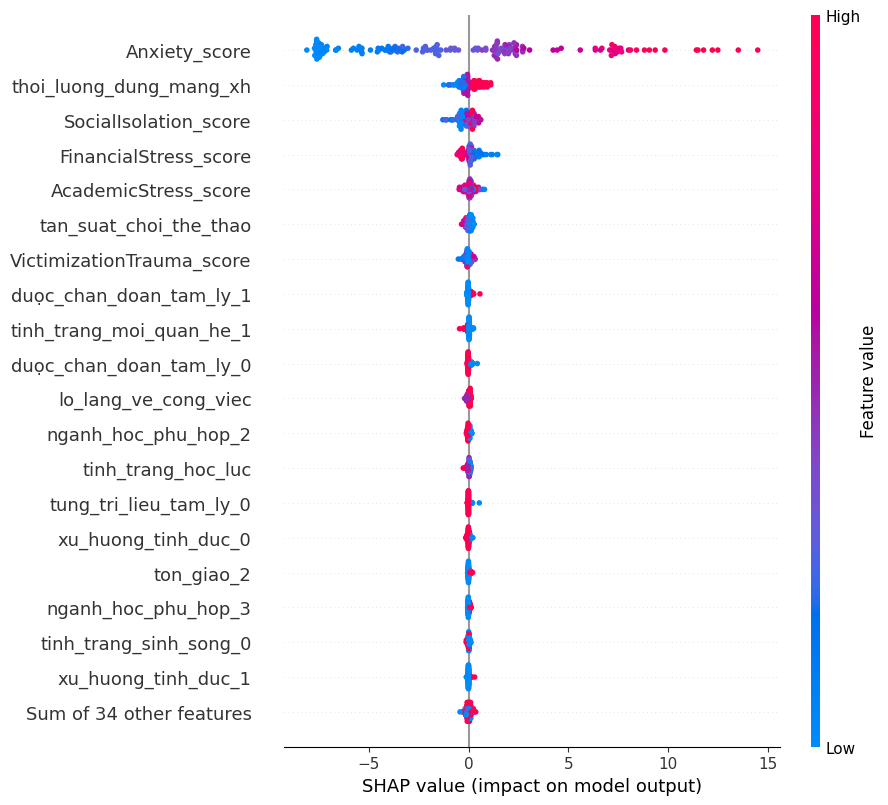

In [44]:
# ============================================================
# 9. GLOBAL SHAP
# ============================================================

shap.plots.beeswarm(
    shap_values,
    max_display=20
)

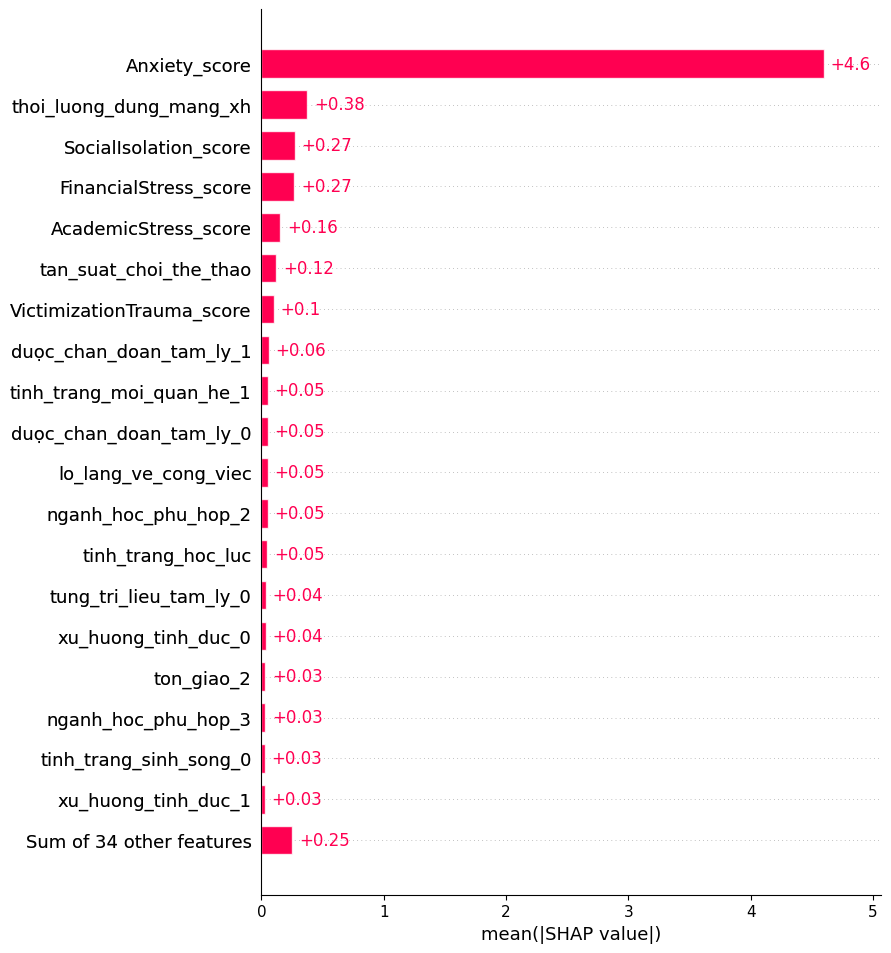

In [45]:
shap.plots.bar(
    shap_values,
    max_display=20
)

In [46]:
global_shap = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(
        shap_values.values
    ).mean(axis=0)
})


global_shap = global_shap.sort_values(
    "mean_abs_shap",
    ascending=False
)


display(
    global_shap.head(20)
)

,feature,mean_abs_shap
0,Anxiety_score,4.597806
8,thoi_luong_dung_mang_xh,0.375219
3,SocialIsolation_score,0.274429
2,FinancialStress_score,0.269834
1,AcademicStress_score,0.156074
7,tan_suat_choi_the_thao,0.121236
4,VictimizationTrauma_score,0.103747
48,duọc_chan_doan_tam_ly_1,0.058589
40,tinh_trang_moi_quan_he_1,0.053452
47,duọc_chan_doan_tam_ly_0,0.052498


In [47]:
# ============================================================
# CELL 1 — SELECT ONE SAMPLE
# ============================================================

import numpy as np
import pandas as pd

# Position inside X_test
sample_idx = 0

# Original row before preprocessing
sample_original = X_test.iloc[sample_idx]

# Original dataframe index
original_index = X_test.index[sample_idx]

# True and predicted PHQ
actual_phq = float(y_test.iloc[sample_idx])
predicted_phq = float(y_pred[sample_idx])

# SHAP explanation for this row
sample_shap = shap_values[sample_idx]


# ------------------------------------------------------------
# Build local SHAP table
# ------------------------------------------------------------

local_explanation = pd.DataFrame({
    "feature": feature_names,
    "standardized_value": X_test_shap.iloc[sample_idx].values,
    "shap_value": sample_shap.values
})

local_explanation["abs_shap"] = (
    local_explanation["shap_value"].abs()
)

local_explanation = (
    local_explanation
    .sort_values("abs_shap", ascending=False)
    .reset_index(drop=True)
)


print("=" * 60)
print("INDIVIDUAL PREDICTION")
print("=" * 60)

print(f"Original index : {original_index}")
print(f"Actual PHQ     : {actual_phq:.3f}")
print(f"Predicted PHQ  : {predicted_phq:.3f}")
print(f"Prediction err : {predicted_phq - actual_phq:+.3f}")

print("\nTop predictive features:")
display(local_explanation.head(10))

INDIVIDUAL PREDICTION
Original index : 610
Actual PHQ     : 27.000
Predicted PHQ  : 24.881
Prediction err : -2.119

Top predictive features:


,feature,standardized_value,shap_value,abs_shap
0,Anxiety_score,2.530368,14.493012,14.493012
1,FinancialStress_score,-0.738108,0.198559,0.198559
2,thoi_luong_dung_mang_xh,1.046970,0.181684,0.181684
3,gioi_tinh_0,1.000000,0.095287,0.095287
4,SocialIsolation_score,2.174657,0.094817,0.094817
5,tan_suat_choi_the_thao,-0.424704,0.088507,0.088507
6,AcademicStress_score,2.597561,0.086698,0.086698
7,lam_them_1,1.000000,0.075867,0.075867
8,gioi_tinh_1,0.000000,0.074267,0.074267
9,ton_giao_0,0.000000,-0.073964,0.073964


In [48]:
# ============================================================
# CELL 2 — LATENT FACTORS FOR THIS SAMPLE
# ============================================================

latent_names = [
    "Anxiety_score",
    "AcademicStress_score",
    "FinancialStress_score",
    "SocialIsolation_score",
    "VictimizationTrauma_score",
]


# Keep only latent features from SHAP
local_latent_shap = local_explanation[
    local_explanation["feature"].isin(latent_names)
].copy()


# Add ORIGINAL latent score
local_latent_shap["original_value"] = (
    local_latent_shap["feature"]
    .map(sample_original)
)


# Rearrange columns
local_latent_shap = local_latent_shap[
    [
        "feature",
        "original_value",
        "standardized_value",
        "shap_value",
        "abs_shap"
    ]
]


local_latent_shap = (
    local_latent_shap
    .sort_values(
        "abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 60)
print("LATENT FACTORS — INDIVIDUAL LEVEL")
print("=" * 60)

display(local_latent_shap)

LATENT FACTORS — INDIVIDUAL LEVEL


,feature,original_value,standardized_value,shap_value,abs_shap
0,Anxiety_score,1.789917,2.530368,14.493012,14.493012
1,FinancialStress_score,-0.380185,-0.738108,0.198559,0.198559
2,SocialIsolation_score,1.087352,2.174657,0.094817,0.094817
3,AcademicStress_score,1.428065,2.597561,0.086698,0.086698
4,VictimizationTrauma_score,0.009891,0.040691,0.059076,0.059076


In [49]:
# ============================================================
# CELL 3 — EXTRACT STRUCTURAL PATHS FROM SEM
# ============================================================

sem_params = med_model.inspect()


# Structural paths only
sem_structural = sem_params[
    (sem_params["op"] == "~") &
    (
        sem_params["lval"]
        .isin(["Anxiety", "Depression"])
    )
][
    [
        "lval",
        "rval",
        "Estimate",
        "Std. Err",
        "p-value"
    ]
].copy()


# Convert numeric columns safely
for col in ["Estimate", "p-value"]:
    sem_structural[col] = pd.to_numeric(
        sem_structural[col],
        errors="coerce"
    )


# Significant paths
significant_paths = sem_structural[
    sem_structural["p-value"] < 0.05
].copy()


print("=" * 60)
print("SIGNIFICANT SEM PATHS")
print("=" * 60)

display(significant_paths)

SIGNIFICANT SEM PATHS


,lval,rval,Estimate,Std. Err,p-value
0,Anxiety,AcademicStress,0.493560,0.063979,1.221245e-14
2,Anxiety,SocialIsolation,0.474230,0.058656,6.661338e-16
3,Anxiety,VictimizationTrauma,0.273283,0.098139,5.358472e-03
4,Depression,Anxiety,0.744519,0.043298,0.000000e+00
6,Depression,FinancialStress,-0.078640,0.035384,2.625193e-02
7,Depression,SocialIsolation,0.093438,0.037325,1.230290e-02


In [50]:
# ============================================================
# CELL 4 — PERSONALIZED SEM + SHAP EXPLANATION
# ============================================================

ml_to_sem = {
    "Anxiety_score": "Anxiety",
    "AcademicStress_score": "AcademicStress",
    "FinancialStress_score": "FinancialStress",
    "SocialIsolation_score": "SocialIsolation",
    "VictimizationTrauma_score": "VictimizationTrauma",
}

sem_to_ml = {
    sem_name: ml_name
    for ml_name, sem_name in ml_to_sem.items()
}


# ------------------------------------------------------------
# 1. Find dominant latent predictive driver
# ------------------------------------------------------------

dominant_row = local_latent_shap.loc[
    local_latent_shap["abs_shap"].idxmax()
]

dominant_ml = dominant_row["feature"]
dominant_sem = ml_to_sem[dominant_ml]

dominant_score = float(
    dominant_row["original_value"]
)

dominant_shap = float(
    dominant_row["shap_value"]
)


print("=" * 60)
print("DOMINANT LATENT PREDICTIVE DRIVER")
print("=" * 60)

print(f"Feature          : {dominant_sem}")
print(f"Individual score : {dominant_score:.3f}")
print(f"SHAP contribution: {dominant_shap:+.3f}")


# ------------------------------------------------------------
# 2. Find significant SEM pathways INTO dominant feature
# ------------------------------------------------------------

upstream_paths = significant_paths[
    significant_paths["lval"] == dominant_sem
].copy()


# ------------------------------------------------------------
# 3. Add individual information
# ------------------------------------------------------------

personalized_rows = []

for _, path in upstream_paths.iterrows():

    source_sem = path["rval"]
    source_ml = sem_to_ml.get(source_sem)

    if source_ml is None:
        continue

    individual_info = local_latent_shap[
        local_latent_shap["feature"] == source_ml
    ]

    if individual_info.empty:
        continue

    individual_info = individual_info.iloc[0]

    personalized_rows.append({

        "source": source_sem,
        "target": dominant_sem,

        "SEM_beta": float(
            path["Estimate"]
        ),

        "SEM_p": float(
            path["p-value"]
        ),

        "individual_score": float(
            individual_info["original_value"]
        ),

        "individual_SHAP": float(
            individual_info["shap_value"]
        )
    })


personalized_paths = pd.DataFrame(
    personalized_rows
)


print("\n" + "=" * 60)
print("UPSTREAM STRUCTURAL CONTEXT")
print("=" * 60)

display(personalized_paths)

DOMINANT LATENT PREDICTIVE DRIVER
Feature          : Anxiety
Individual score : 1.790
SHAP contribution: +14.493

UPSTREAM STRUCTURAL CONTEXT


,source,target,SEM_beta,SEM_p,individual_score,individual_SHAP
0,AcademicStress,Anxiety,0.493560,1.221245e-14,1.428065,0.086698
1,SocialIsolation,Anxiety,0.474230,6.661338e-16,1.087352,0.094817
2,VictimizationTrauma,Anxiety,0.273283,5.358472e-03,0.009891,0.059076


In [51]:
# ============================================================
# CELL 5 — GENERATE TEXT EXPLANATION
# ============================================================

print("=" * 70)
print("INDIVIDUAL STRUCTURAL-PREDICTIVE EXPLANATION")
print("=" * 70)

print(
    f"\nThe model predicted PHQ = {predicted_phq:.2f} "
    f"(observed PHQ = {actual_phq:.2f})."
)

direction = (
    "increased"
    if dominant_shap > 0
    else "decreased"
)

print(
    f"\nThe dominant latent predictive driver was "
    f"{dominant_sem}."
)

print(
    f"Its individual latent score was "
    f"{dominant_score:.2f}, and it {direction} "
    f"the prediction with SHAP = "
    f"{dominant_shap:+.2f}."
)


if not personalized_paths.empty:

    print(
        "\nAt the structural level, SEM identified "
        "the following significant pathways into "
        f"{dominant_sem}:"
    )

    for _, row in personalized_paths.iterrows():

        print(
            f"  • {row['source']} → "
            f"{row['target']}: "
            f"β = {row['SEM_beta']:+.3f}, "
            f"p = {row['SEM_p']:.4f}; "
            f"individual score = "
            f"{row['individual_score']:+.3f}"
        )


print(
    "\nInterpretation note: SEM paths represent "
    "population-level structural associations, "
    "whereas SHAP values represent contributions "
    "to this individual's model prediction."
)

INDIVIDUAL STRUCTURAL-PREDICTIVE EXPLANATION

The model predicted PHQ = 24.88 (observed PHQ = 27.00).

The dominant latent predictive driver was Anxiety.
Its individual latent score was 1.79, and it increased the prediction with SHAP = +14.49.

At the structural level, SEM identified the following significant pathways into Anxiety:
  • AcademicStress → Anxiety: β = +0.494, p = 0.0000; individual score = +1.428
  • SocialIsolation → Anxiety: β = +0.474, p = 0.0000; individual score = +1.087
  • VictimizationTrauma → Anxiety: β = +0.273, p = 0.0054; individual score = +0.010

Interpretation note: SEM paths represent population-level structural associations, whereas SHAP values represent contributions to this individual's model prediction.


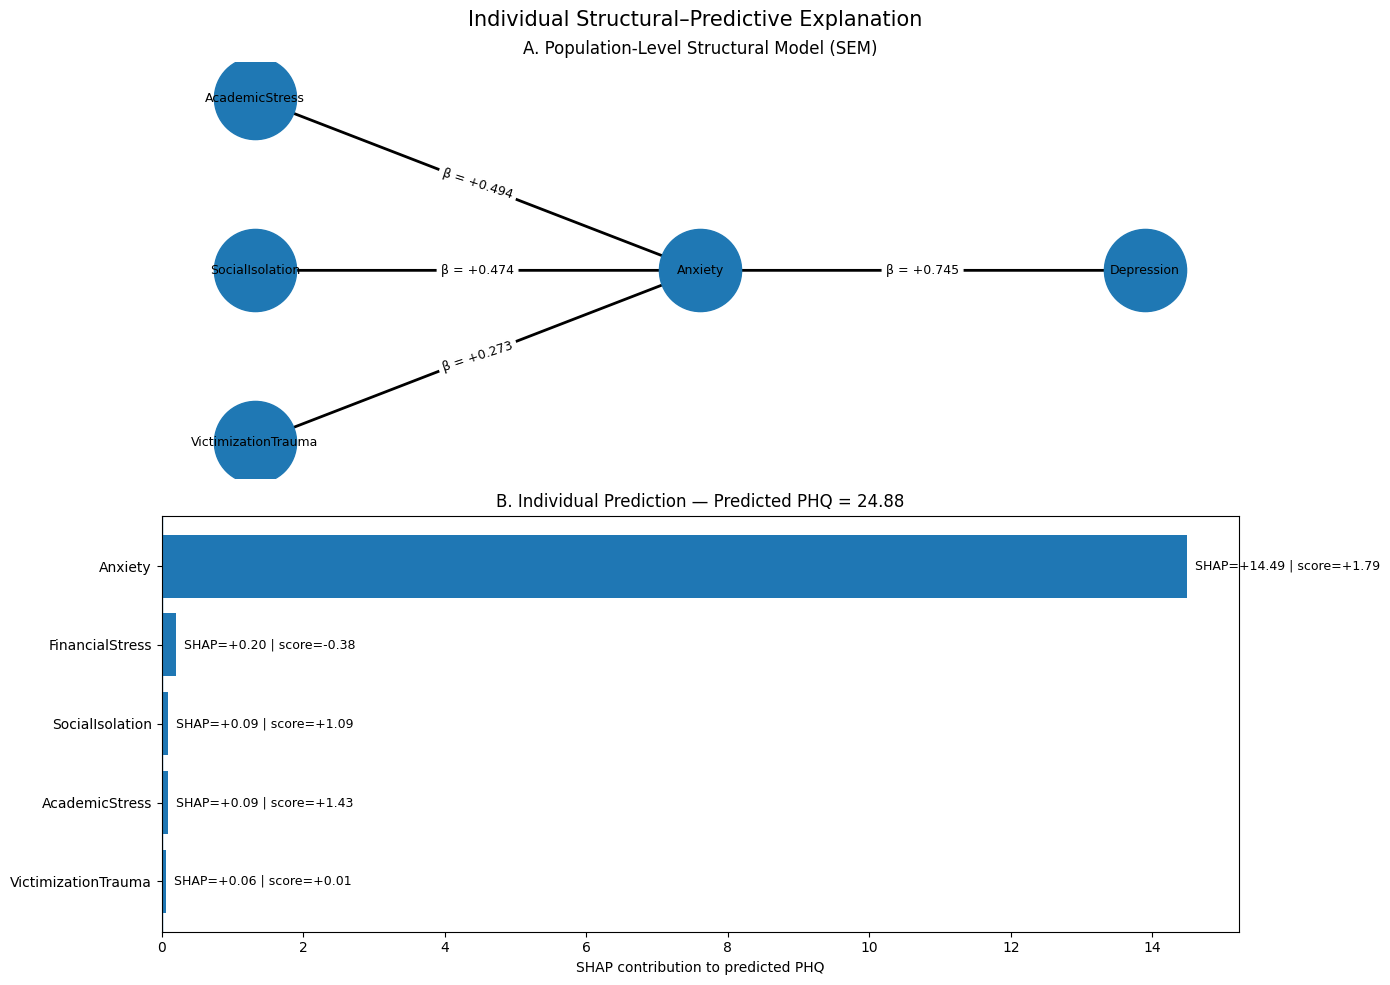

In [52]:
# ============================================================
# CELL 6 — TWO-LEVEL SEM + SHAP EXPLANATION
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 10)
)


# ============================================================
# PANEL A — POPULATION-LEVEL SEM
# ============================================================

ax = axes[0]

G_sem = nx.DiGraph()

sem_edges = [
    (
        row["source"],
        row["target"],
        row["SEM_beta"]
    )
    for _, row in personalized_paths.iterrows()
]

# Add Anxiety -> Depression
anxiety_dep = significant_paths[
    (significant_paths["rval"] == "Anxiety") &
    (significant_paths["lval"] == "Depression")
]

if not anxiety_dep.empty:

    beta_anx_dep = float(
        anxiety_dep.iloc[0]["Estimate"]
    )

    sem_edges.append(
        (
            "Anxiety",
            "Depression",
            beta_anx_dep
        )
    )


for source, target, beta in sem_edges:

    G_sem.add_edge(
        source,
        target,
        beta=beta
    )


# positions
upstream_nodes = personalized_paths[
    "source"
].tolist()

pos_sem = {}

y_positions = np.linspace(
    1,
    -1,
    len(upstream_nodes)
)

for node, y in zip(
    upstream_nodes,
    y_positions
):
    pos_sem[node] = (0, y)

pos_sem["Anxiety"] = (2, 0)
pos_sem["Depression"] = (4, 0)


nx.draw_networkx_nodes(
    G_sem,
    pos_sem,
    node_size=3500,
    ax=ax
)

nx.draw_networkx_labels(
    G_sem,
    pos_sem,
    font_size=9,
    ax=ax
)

nx.draw_networkx_edges(
    G_sem,
    pos_sem,
    arrows=True,
    arrowsize=20,
    width=2,
    ax=ax
)


sem_edge_labels = {
    (u, v):
        f"β = {d['beta']:+.3f}"
    for u, v, d
    in G_sem.edges(data=True)
}


nx.draw_networkx_edge_labels(
    G_sem,
    pos_sem,
    edge_labels=sem_edge_labels,
    font_size=9,
    ax=ax
)


ax.set_title(
    "A. Population-Level Structural Model (SEM)"
)

ax.axis("off")


# ============================================================
# PANEL B — INDIVIDUAL SHAP
# ============================================================

ax = axes[1]

individual_df = (
    local_latent_shap
    .sort_values(
        "shap_value"
    )
)


features_display = (
    individual_df["feature"]
    .str.replace(
        "_score",
        "",
        regex=False
    )
)


ax.barh(
    features_display,
    individual_df["shap_value"]
)


ax.axvline(
    0,
    linewidth=1
)


ax.set_xlabel(
    "SHAP contribution to predicted PHQ"
)


ax.set_title(
    f"B. Individual Prediction — "
    f"Predicted PHQ = {predicted_phq:.2f}"
)


# labels
for i, (_, row) in enumerate(
    individual_df.iterrows()
):

    shap_val = row["shap_value"]
    original_val = row["original_value"]

    ax.text(
        shap_val,
        i,
        (
            f"  SHAP={shap_val:+.2f}"
            f" | score={original_val:+.2f}"
        ),
        va="center",
        fontsize=9
    )


plt.suptitle(
    "Individual Structural–Predictive Explanation",
    fontsize=15
)

plt.tight_layout()
plt.show()

## Ablation study

In [ ]:
# ============================================================
# ABLATION STUDY (LEAKAGE-SAFE)
# ============================================================

from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Feature groups
# ------------------------------------------------------------

latent_features = [
    "Anxiety_score",
    "AcademicStress_score",
    "FinancialStress_score",
    "SocialIsolation_score",
    "VictimizationTrauma_score",
]

latent_without_anxiety = [
    "AcademicStress_score",
    "FinancialStress_score",
    "SocialIsolation_score",
    "VictimizationTrauma_score",
]

categorical_features = [
    "gioi_tinh",
    "xu_huong_tinh_duc",
    "ton_giao",
    "tinh_trang_sinh_song",
    "nganh_hoc_phu_hop",
    "lam_them",
    "tinh_trang_moi_quan_he",
    "co_choi_the_thao",
    "bị_benh_man_tinh",
    "duọc_chan_doan_tam_ly",
    "tung_tri_lieu_tam_ly",
]

numeric_observed_features = [
    "tinh_trang_hoc_luc",
    "lo_lang_ve_cong_viec",
    "tan_suat_choi_the_thao",
    "thoi_luong_dung_mang_xh",
]

observed_features = (
    numeric_observed_features
    + categorical_features
)

In [ ]:
# ------------------------------------------------------------
# 2. Ablation configurations
# ------------------------------------------------------------

ablation_sets = {
    "Observed only": {
        "use_latent": False,
        "latent_subset": [],
        "numeric": numeric_observed_features,
        "categorical": categorical_features,
    },

    "Latent only": {
        "use_latent": True,
        "latent_subset": latent_features,
        "numeric": latent_features,
        "categorical": [],
    },

    "Latent + Observed": {
        "use_latent": True,
        "latent_subset": latent_features,
        "numeric": latent_features + numeric_observed_features,
        "categorical": categorical_features,
    },

    "Without Anxiety": {
        "use_latent": True,
        "latent_subset": latent_without_anxiety,
        "numeric": latent_without_anxiety + numeric_observed_features,
        "categorical": categorical_features,
    },
}

In [ ]:
# select the best model from previous CV results
best_model_name = cv_results_df.iloc[0]["Model"]
ablation_model = models[best_model_name]

In [ ]:
# ------------------------------------------------------------
# 3. Helper function
# ------------------------------------------------------------

def make_preprocessor(numeric_cols, categorical_cols):

    transformers = []

    if len(numeric_cols) > 0:
        numeric_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )

        transformers.append(
            ("num", numeric_pipeline, numeric_cols)
        )

    if len(categorical_cols) > 0:
        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                ),
            ]
        )

        transformers.append(
            ("cat", categorical_pipeline, categorical_cols)
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )

In [ ]:
# ------------------------------------------------------------
# 4. Same CV splitter for all experiments
# ------------------------------------------------------------

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

ablation_idx = df_ml_base.index.to_numpy()

In [ ]:
# ------------------------------------------------------------
# 5. Run ablation with CFA-imputation inside each fold
# ------------------------------------------------------------

ablation_results = []

for experiment_name, config in ablation_sets.items():
    numeric_cols = config["numeric"]
    categorical_cols = config["categorical"]
    use_latent = config["use_latent"]
    latent_subset = config["latent_subset"]

    fold_r2 = []
    fold_mae = []
    fold_rmse = []

    for fold_train_pos, fold_val_pos in cv.split(ablation_idx):
        fold_train_idx = ablation_idx[fold_train_pos]
        fold_val_idx = ablation_idx[fold_val_pos]

        fold_train_parts = []
        fold_val_parts = []

        if use_latent:
            fold_train_latent, fold_val_latent = fit_cfa_scores_in_fold(
                train_items=df_ml_base.loc[fold_train_idx, predictor_items],
                eval_items=df_ml_base.loc[fold_val_idx, predictor_items],
            )
            fold_train_parts.append(fold_train_latent[latent_subset])
            fold_val_parts.append(fold_val_latent[latent_subset])

        observed_numeric = [c for c in numeric_cols if c in numeric_observed_features]
        if len(observed_numeric) > 0:
            fold_train_parts.append(df_ml_base.loc[fold_train_idx, observed_numeric].copy())
            fold_val_parts.append(df_ml_base.loc[fold_val_idx, observed_numeric].copy())

        if len(categorical_cols) > 0:
            fold_train_parts.append(df_ml_base.loc[fold_train_idx, categorical_cols].copy())
            fold_val_parts.append(df_ml_base.loc[fold_val_idx, categorical_cols].copy())

        X_fold_train = pd.concat(fold_train_parts, axis=1)
        X_fold_val = pd.concat(fold_val_parts, axis=1)

        feature_cols = list(dict.fromkeys(numeric_cols + categorical_cols))
        X_fold_train = X_fold_train[feature_cols]
        X_fold_val = X_fold_val[feature_cols]

        y_fold_train = df_ml_base.loc[fold_train_idx, target_col].copy()
        y_fold_val = df_ml_base.loc[fold_val_idx, target_col].copy()

        current_preprocessor = make_preprocessor(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
        )

        fold_pipeline = Pipeline(
            steps=[
                ("preprocessor", current_preprocessor),
                ("model", clone(ablation_model)),
            ]
        )

        fold_pipeline.fit(X_fold_train, y_fold_train)
        y_fold_pred = fold_pipeline.predict(X_fold_val)

        fold_r2.append(r2_score(y_fold_val, y_fold_pred))
        fold_mae.append(mean_absolute_error(y_fold_val, y_fold_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_fold_val, y_fold_pred)))

    feature_count = len(list(dict.fromkeys(numeric_cols + categorical_cols)))
    ablation_results.append({
        "Experiment": experiment_name,
        "N_features_raw": feature_count,
        "R2_mean": np.mean(fold_r2),
        "R2_SD": np.std(fold_r2),
        "MAE_mean": np.mean(fold_mae),
        "MAE_SD": np.std(fold_mae),
        "RMSE_mean": np.mean(fold_rmse),
        "RMSE_SD": np.std(fold_rmse),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values(
    "R2_mean",
    ascending=False,
    ignore_index=True
)

display(ablation_df)